# Lorenz63 MLP Residual Training Cookbook

This notebook trains the current `models.py` MLP residual Neural ODE model. The model uses an unconstrained learnable linear matrix plus an MLP residual component:

`f_theta(x) = A_theta x + G_theta(x)`

The default residual mask in `models.py` is `(1, 1, 1)`, so the residual component is not told the Lorenz63 nonlinear sparsity constraint.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.optim import AdamW

repo_root = Path.cwd()
if repo_root.name == "examples":
    repo_root = repo_root.parent

src_path = repo_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from lorenz63_neuralode.data import get_dataloaders
from lorenz63_neuralode.models import build_lorenz63_model

torch.manual_seed(42)
plt.rcParams.update({"figure.dpi": 120})

repo_root

PosixPath('/srv/data/kezhoulumelody/Lorenz63_NeuralODE')

## Configuration

`MODEL_NAME = "residual_mlp"` builds `Lorenz63ResidualModel` from the current unstructured `models.py`.

In [2]:
MODEL_NAME = "residual_mlp"

DATA_PATH = repo_root / "data" / "lorenz63_trajectory_10-28-2.7.npz"


SIGMA_INIT = 10.0
RHO_INIT = 28
BETA_INIT = 2.7
HIDDEN_DIM = 64
N_HIDDEN_LAYERS = 2

BATCH_SIZE = 256
N_EPOCHS = 500
LR = 1e-3
WEIGHT_DECAY = 1e-3
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

OUTPUT_DIR = repo_root / "outputs" / "unstructured" / f"lorenz63_{MODEL_NAME}.hidden{HIDDEN_DIM}.layers{N_HIDDEN_LAYERS}.normalizedLoss"

# OUTPUT_DIR = repo_root / "outputs" / "unstructured" / f"lorenz63_{MODEL_NAME}"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
SAVE_ARTIFACTS = True
CHECKPOINT_PATH = OUTPUT_DIR / f"lorenz63_{MODEL_NAME}_10-28-2.7_{SIGMA_INIT}-{RHO_INIT}-{BETA_INIT}.pt"
CURVE_PATH = OUTPUT_DIR / f"lorenz63_{MODEL_NAME}_10-28-2.7_{SIGMA_INIT}-{RHO_INIT}-{BETA_INIT}_curves.png"

print(f"device: {DEVICE}")
print(f"data: {DATA_PATH}")
print(f"output: {OUTPUT_DIR}")

device: cuda
data: /srv/data/kezhoulumelody/Lorenz63_NeuralODE/data/lorenz63_trajectory_10-28-2.7.npz
output: /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/unstructured/lorenz63_residual_mlp.hidden64.layers2.normalizedLoss


## Load Data And Build Model

In [3]:
train_loader, test_loader = get_dataloaders(
    npz_path=DATA_PATH,
    batch_size=BATCH_SIZE,
)

model = build_lorenz63_model(
    model_name=MODEL_NAME,
    sigma_init=SIGMA_INIT,
    rho_init=RHO_INIT,
    beta_init=BETA_INIT,
    hidden_dim=HIDDEN_DIM,
    n_hidden_layers=N_HIDDEN_LAYERS,
).to(DEVICE)

optimizer = AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
loss_fn = nn.MSELoss()

n_train = len(train_loader.dataset)
n_test = len(test_loader.dataset)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"train samples: {n_train}, test samples: {n_test}")
print(f"trainable parameters: {n_params}")
print(f"initial learned A:\n{model.A.detach().cpu()}")
print(f"residual mask: {model.residual_mask.detach().cpu().tolist()}")

Lorenz63ResidualModel(
  (linear): UnstructuredLorenz63Linear()
  (residual_net): ResidualMLP(
    (net): Sequential(
      (0): Linear(in_features=3, out_features=64, bias=True)
      (1): Tanh()
      (2): Linear(in_features=64, out_features=64, bias=True)
      (3): Tanh()
      (4): Linear(in_features=64, out_features=3, bias=True)
    )
  )
)
train samples: 80000, test samples: 20000
trainable parameters: 4620
initial learned A:
tensor([[-10.0000,  10.0000,   0.0000],
        [ 28.0000,  -1.0000,   0.0000],
        [  0.0000,   0.0000,  -2.7000]])
residual mask: [1.0, 1.0, 1.0]


## Metric Helpers

`evaluate_split` returns overall RMSE, component-wise RMSE for `dx/dt`, `dy/dt`, and `dz/dt`, plus overall and component-wise anomaly correlation coefficient.

In [4]:
@torch.no_grad()
def evaluate_split(model, dataloader, device):
    model.eval()
    preds = []
    targets = []

    for batch in dataloader:
        state = batch["state"].to(device)
        target = batch["dxdt"].to(device)
        pred = model(state)
        preds.append(pred.detach().cpu())
        targets.append(target.detach().cpu())

    pred = torch.cat(preds, dim=0)
    target = torch.cat(targets, dim=0)
    err = pred - target

    eps = 1e-12
    rmse = torch.sqrt(torch.mean(err ** 2))
    component_rmse = torch.sqrt(torch.mean(err ** 2, dim=0))

    target_mean = torch.mean(target, dim=0, keepdim=True)
    pred_anom = pred - target_mean
    target_anom = target - target_mean

    acc_numerator = torch.sum(pred_anom * target_anom)
    acc_denominator = torch.sqrt(torch.sum(pred_anom ** 2) * torch.sum(target_anom ** 2)).clamp_min(eps)
    acc = acc_numerator / acc_denominator

    component_acc_numerator = torch.sum(pred_anom * target_anom, dim=0)
    component_acc_denominator = torch.sqrt(
        torch.sum(pred_anom ** 2, dim=0) * torch.sum(target_anom ** 2, dim=0)
    ).clamp_min(eps)
    component_acc = component_acc_numerator / component_acc_denominator

    return {
        "rmse": float(rmse),
        "component_rmse": [float(v) for v in component_rmse],
        "acc": float(acc),
        "component_acc": [float(v) for v in component_acc],
    }


def append_metrics(history, prefix, metrics):
    history[f"{prefix}_rmse"].append(metrics["rmse"])
    history[f"{prefix}_component_rmse"].append(metrics["component_rmse"])
    history[f"{prefix}_acc"].append(metrics["acc"])
    history[f"{prefix}_component_acc"].append(metrics["component_acc"])

## Train

The loop evaluates both train and test splits after each epoch so the curves below show in-sample and out-of-sample behavior.

In [5]:
history = {
    "epoch": [],
    "train_loss": [],
    "train_rmse": [],
    "test_rmse": [],
    "train_component_rmse": [],
    "test_component_rmse": [],
    "train_acc": [],
    "test_acc": [],
    "train_component_acc": [],
    "test_component_acc": [],
}

for epoch in range(1, N_EPOCHS + 1):
    model.train()
    total_loss = 0.0
    n_samples = 0

    for batch in train_loader:
        state = batch["state"].to(DEVICE)
        target = batch["dxdt"].to(DEVICE)

        pred = model(state)
        loss = loss_fn(pred, target)

        optimizer.zero_grad(set_to_none=True)
        loss.backward()
        optimizer.step()

        batch_n = state.shape[0]
        total_loss += loss.item() * batch_n
        n_samples += batch_n

    train_loss = total_loss / max(n_samples, 1)
    train_metrics = evaluate_split(model, train_loader, DEVICE)
    test_metrics = evaluate_split(model, test_loader, DEVICE)

    history["epoch"].append(epoch)
    history["train_loss"].append(float(train_loss))
    append_metrics(history, "train", train_metrics)
    append_metrics(history, "test", test_metrics)

    if epoch == 1 or epoch % 10 == 0 or epoch == N_EPOCHS:
        print(
            f"epoch {epoch:04d} | "
            f"loss {train_loss:.6f} | "
            f"train RMSE {train_metrics['rmse']:.6f} | "
            f"test RMSE {test_metrics['rmse']:.6f} | "
            f"train ACC {train_metrics['acc']:.4f} | "
            f"test ACC {test_metrics['acc']:.4f}"
        )

epoch 0001 | loss 22090.423556 | train RMSE 142.691254 | test RMSE 141.474533 | train ACC -0.1430 | test ACC -0.1293
epoch 0010 | loss 7082.021236 | train RMSE 81.572350 | test RMSE 80.610123 | train ACC 0.0594 | test ACC 0.0737
epoch 0020 | loss 1677.060602 | train RMSE 39.185627 | test RMSE 38.591152 | train ACC 0.8011 | test ACC 0.8063
epoch 0030 | loss 287.886232 | train RMSE 16.207891 | test RMSE 15.865873 | train ACC 0.9718 | test ACC 0.9727
epoch 0040 | loss 43.798117 | train RMSE 6.281633 | test RMSE 6.178110 | train ACC 0.9955 | test ACC 0.9956
epoch 0050 | loss 7.182725 | train RMSE 2.568533 | test RMSE 2.557063 | train ACC 0.9992 | test ACC 0.9992
epoch 0060 | loss 2.190556 | train RMSE 1.436839 | test RMSE 1.407032 | train ACC 0.9998 | test ACC 0.9998
epoch 0070 | loss 1.124380 | train RMSE 1.029554 | test RMSE 0.991691 | train ACC 0.9999 | test ACC 0.9999
epoch 0080 | loss 0.804128 | train RMSE 0.823570 | test RMSE 0.796539 | train ACC 0.9999 | test ACC 0.9999
epoch 0090 |

KeyboardInterrupt: 

## Learning Curves

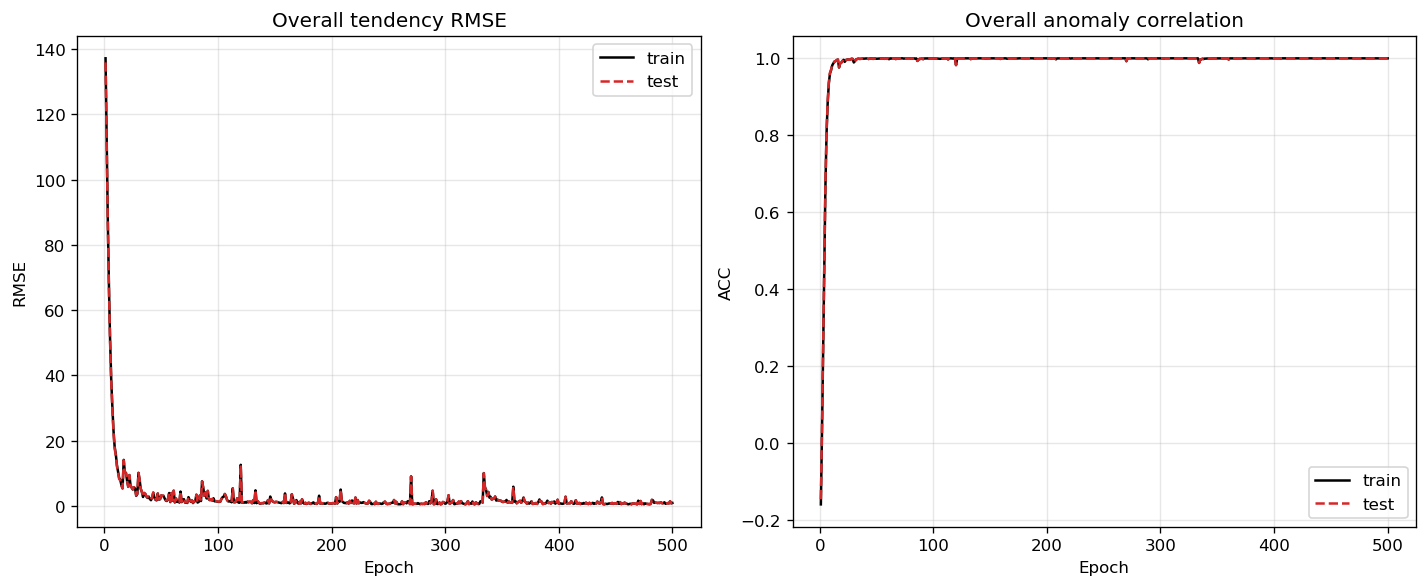

In [ ]:
epochs = history["epoch"]
component_names = ("dx/dt", "dy/dt", "dz/dt")
component_colors = ("tab:blue", "tab:orange", "tab:green")

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(epochs, history["train_rmse"], label="train", color="black")
axes[0].plot(epochs, history["test_rmse"], label="test", color="tab:red", linestyle="--")
axes[0].set_title("Overall tendency RMSE")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("RMSE")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs, history["train_acc"], label="train", color="black")
axes[1].plot(epochs, history["test_acc"], label="test", color="tab:red", linestyle="--")
axes[1].set_title("Overall anomaly correlation")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("ACC")
axes[1].legend()
axes[1].grid(alpha=0.3)

fig.tight_layout()
# if SAVE_ARTIFACTS:
#     fig.savefig(CURVE_PATH, dpi=200)
#     print(f"saved curves to {CURVE_PATH}")
plt.show()

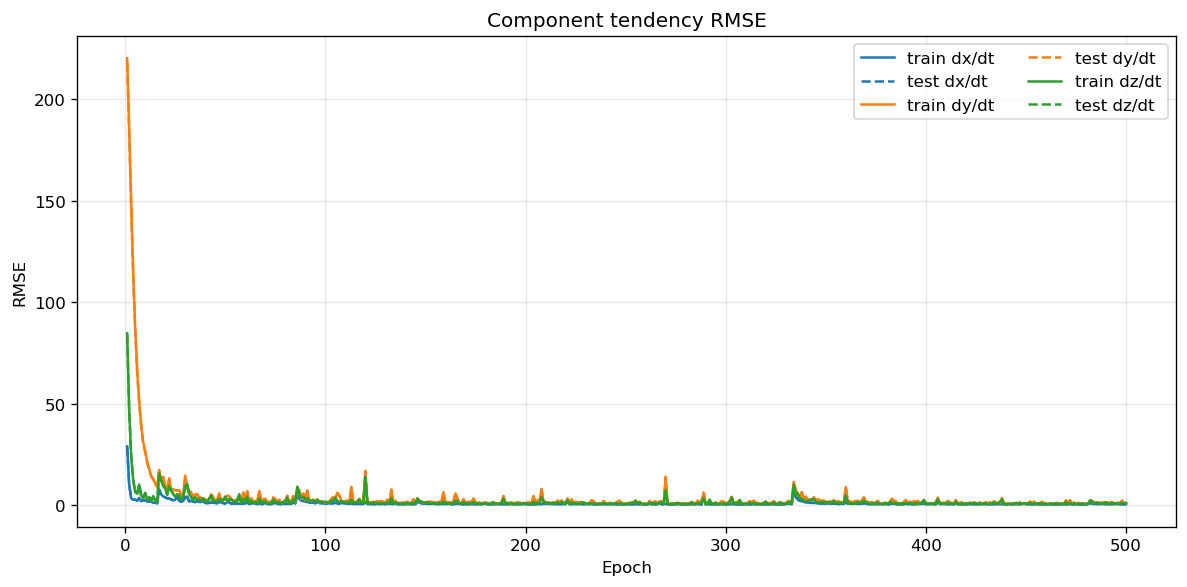

In [ ]:
train_component_rmse = torch.tensor(history["train_component_rmse"])
test_component_rmse = torch.tensor(history["test_component_rmse"])

fig, ax = plt.subplots(figsize=(10, 5))

for idx, (name, color) in enumerate(zip(component_names, component_colors)):
    ax.plot(epochs, train_component_rmse[:, idx], label=f"train {name}", color=color)
    ax.plot(epochs, test_component_rmse[:, idx], label=f"test {name}", color=color, linestyle="--")

ax.set_title("Component tendency RMSE")
ax.set_xlabel("Epoch")
ax.set_ylabel("RMSE")
ax.legend(ncol=2)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## Final Metrics

In [ ]:
final = {
    "train_rmse": history["train_rmse"][-1],
    "test_rmse": history["test_rmse"][-1],
    "train_acc": history["train_acc"][-1],
    "test_acc": history["test_acc"][-1],
    "train_component_rmse": dict(zip(component_names, history["train_component_rmse"][-1])),
    "test_component_rmse": dict(zip(component_names, history["test_component_rmse"][-1])),
}

final

{'train_rmse': 0.9340044856071472,
 'test_rmse': 0.9516113996505737,
 'train_acc': 0.9998959302902222,
 'test_acc': 0.9998912215232849,
 'train_component_rmse': {'dx/dt': 0.539662778377533,
  'dy/dt': 1.0724033117294312,
  'dz/dt': 1.084347128868103},
 'test_component_rmse': {'dx/dt': 0.5337947607040405,
  'dy/dt': 1.1079134941101074,
  'dz/dt': 1.0973985195159912}}

## Save Checkpoint

In [ ]:
if SAVE_ARTIFACTS:
    checkpoint_params = {
        "model_name": MODEL_NAME,
        "sigma_init": SIGMA_INIT,
        "rho_init": RHO_INIT,
        "beta_init": BETA_INIT,
        "hidden_dim": HIDDEN_DIM,
        "n_hidden_layers": N_HIDDEN_LAYERS,
        "residual_mask": model.residual_mask.detach().cpu(),
        "learned_A": model.A.detach().cpu() if hasattr(model, "A") else None,
    }

    torch.save(
        {
            "model_state_dict": model.state_dict(),
            "history": history,
            "params": checkpoint_params,
        },
        CHECKPOINT_PATH,
    )
    print(f"saved checkpoint to {CHECKPOINT_PATH}")
    print("saved params:")
    print(checkpoint_params)

saved checkpoint to /srv/data/kezhoulumelody/Lorenz63_NeuralODE/outputs/unstructured/lorenz63_transformer.hidden64.layers2/lorenz63_transformer_10-28-2.7_10.0-28-2.7.pt
saved params:
{'model_name': 'transformer', 'sigma_init': 10.0, 'rho_init': 28, 'beta_init': 2.7, 'hidden_dim': 64, 'n_hidden_layers': 2, 'residual_mask': tensor([1., 1., 1.]), 'learned_A': tensor([[-9.1880,  9.6918,  0.0332],
        [19.6272, -3.3196, -0.9398],
        [-0.2441,  0.3133, -1.9690]])}
